# Intégration d'EDO sur Python

## 1- Solution numérique

### 1-a. Installation des bibliothèques et importation des modules d'intégration

In [1]:
conda install matplotlib numpy

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [1]:
# numpy: calcul, matplotlib: graphiques, scipy: intégration

# module scipy.integrate pour l'intégration
# ivp : Inital value problem (problème à condition initiale)

import scipy as scp

#attention: bien le nommer scp et non sp (voir plus loin, une autre bibliothèque s'appelle aussi sp (abréviation de sympy))

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

### 1-b. Définition de l'équation différentielle

On s'intéresse à l'EDO suivante : $ \dfrac{dL}{dt} = 3L $, avec une condition initiale $ L(0)=1 $

Le code représentant cette EDO est le suivant : 

In [2]:
def equation(t, L):

# equation représente la dérivée dL/dt.

#Paramètres
    
    #t : float
    #    Temps courant.
    #   Fourni automatiquement par solve_ivp.

    #L : float ou ndarray
    #    Valeur courante de la variable L à un instant t

# Retour
    
    #float ou ndarray
    # Valeur de la dérivée dL/dt à modifier en fonction de l'EDO

    return 3 * L


### 1-c. Définition des conditions initiales


In [3]:
y0 = [1]

# La fonction qui va résoudre l'EDO (solve_ivp) 
# attend une liste pour la valeur de L en condition initiale

### 1-d. Intervalle d'intégration et nombre de points d'évaluation

In [4]:
t0 = 0
tf = 2
t_eval=np.linspace(t0, tf, 200)

#np.linspace(a,b,n) crée n points régulièrement espacés entre a et b

### 1-e. Résolution numérique

In [5]:
solution = solve_ivp(
    fun=equation,
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval)

# Paramètres utilisés :

    #fun :  fonction définissant l'équation différentielle,
    # t_span : intervalle de temps étudié
    #y0 :condition initiale.
    #t_eval :instants où l'on souhaite récupérer la solution

#Fonctionnement

    #solve_ip fournit les arguments à equation (t et y) 
    #selon les instructions d'incrémentation fournies par t_eval
    #sorte de boucle qui calcule toutes les valeurs prises par equation (soit dL/dt)
    #en fonction des valeurs de t et de y
    #en partant des conditions initiales

# Résultat :

    #solution.t: contient les temps.
    #solution.y: contient les valeurs calculées.

### 1-e. Extraction des résultats

In [6]:
t_num = solution.t

L_num = solution.y[0]

# solution.y est un tableau numpy 2D 
# Pour une seule équation : solution.y[0] contient les valeurs de dL/dt calculées
#rangées en une seule colonne correspondant à la variable dL/dt
#solution.t est aussi un tableau (1D)

### 1- f. Affichage résultats

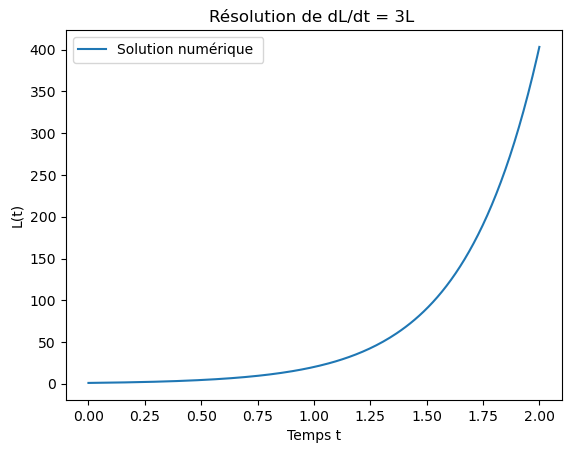

In [7]:
# trace la solution numérique
# t_num :  axe des x
#L_num: axe des y 
#label: légende associée au grahpique 

plt.plot(
    t_num,
    L_num,
    label="Solution numérique ")

# chercher la solution analytique (à coder) puis la superposer graphiquement 

plt.xlabel("Temps t")

# nom de l'axe horizontal

plt.ylabel("L(t)")

# nom de l'axe vertical


plt.title("Résolution de dL/dt = 3L ")

# titre du graphique

plt.legend()

# affiche les légendes

plt.show()

# affiche la figure à l'écran

## 2- Solution analytique

### 2-a.  Installation des bibliothèques et importation des modules d'intégration

Installation:

In [8]:
conda install sympy matplotlib numpy

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


Importation: 

In [9]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

### 2.b- Définition de la variable indépendante

In [10]:
t = sp.Symbol('t')
# Symbol représente une variable mathématique symbolique.
# Ici t joue le rôle du temps.

### 2.c- Définition de la fonction inconnue

In [11]:
L = sp.Function('L')
# Function crée une fonction symbolique.
# L(t) représente l'inconnue de l'équation.

### 2.d- Définition de l'EDO

In [12]:
equation = sp.Eq(
    sp.Derivative(L(t), t),
    3 * L(t))

# Eq construit une égalité mathématique sp.Eq(membre gauche, membre droit)
#
# Derivative(L(t), t) représente dL/dt.
#
# Et ici :
# dL/dt = 3L 
# Valeur de la dérivée dL/dt à modifier en fonction de l'EDO


### 2.e- Résolution analytique d'une EDO avec condition initiale

In [13]:
solution_ci = sp.dsolve(
    equation,
    ics={L(0): 1})

print("Solution avec condition initiale :")
sp.pprint(solution_ci)

# dsolve :
# Fonction principale de SymPy pour résoudre les EDO.
#
# Elle prend une équation différentielle en argument (equation)
# et une condition initiale: ics (dictionnaire)
# et retourne la solution analytique.

#forme de solution_ci: Eq(L(t), expression littérale)
#
#sp.pprint : comme print, affiche le résultat


Solution avec condition initiale :
        3⋅t
L(t) = ℯ   


### 2.f- Transformation de la solution pour le tracé

In [14]:
# Extraction du membre de droite
expression = solution_ci.rhs

#.rhs : membre de droite de l'équation, extrait depuis l'objet solution_ci
#en opposition avec .lhs, membre de gauche de l'équation

#conversion en fonction numérique

fonction_numerique = sp.lambdify(
    t,
    expression,
    modules=["numpy"])

#sp.lamdify : transforme une expression symbolique SymPy en fonction 


### 2- g. Affichage résultats

In [1]:
#création de 200 points entre t0 et tf par np.linspace

t_values = np.linspace(0, 2, 200)

# calcul de L(t) pour toutes les valeurs de t stockées dans t_values
# par la fonction créée en 2.f- (fonction_numerique)

L_values = fonction_numerique(t_values)

#tracé du graphique issu de la solution analytique

plt.plot(
    t_values,
    L_values,
    label="L(t)=e^(3t)")

# t_values :  axe des x
#L_values: axe des y 
#label: légende associée au graphique

plt.xlabel("t")

# nom de l'axe horizontal

plt.ylabel("L(t)")

# nom de l'axe vertical

plt.title("Solution de dL/dt = 3L")

# titre du graphique

plt.legend()

# affiche les légendes

plt.show()

# affiche la figure à l'écran

NameError: name 'np' is not defined